In [8]:
import pandas as pd

hh_2002 = pd.read_stata('data/UZHH49DT.DTA')
ind_2002 = pd.read_stata('data/UZIQ49DT.DTA')
hh_1996 = pd.read_stata('data/UZHR31DT.DTA')
ind_1996 = pd.read_stata('data/UZIR31DT.DTA')
wi_1996 = pd.read_stata('data/UZWI31DT.DTA')

print(hh_2002.shape, hh_1996.shape)
print(hh_2002.columns.tolist()[:20])
print(hh_1996.columns.tolist()[:20])

FileNotFoundError: [Errno 2] No such file or directory: 'data/UZHH49DT.DTA'

In [ ]:
import pandas as pd

hh_2002 = pd.read_stata('data/UZHH49DT.DTA')
ind_2002 = pd.read_stata('data/UZIQ49DT.DTA')
hh_1996 = pd.read_stata('data/UZHR31DT.DTA')
ind_1996 = pd.read_stata('data/UZIR31DT.DTA')
wi_1996 = pd.read_stata('data/UZWI31DT.DTA')

print(hh_2002.shape, hh_1996.shape)
print(hh_2002.columns.tolist()[:20])
print(hh_1996.columns.tolist()[:20])

FileNotFoundError: [Errno 2] No such file or directory: 'data/UZHH49DT.DTA'

In [1]:
import pandas as pd

hh_2002 = pd.read_stata('data/UZHH49DT.DTA')
ind_2002 = pd.read_stata('data/UZIQ49DT.DTA')
hh_1996 = pd.read_stata('data/UZHR31DT.DTA')
ind_1996 = pd.read_stata('data/UZIR31DT.DTA')
wi_1996 = pd.read_stata('data/UZWI31DT.DTA')

print(hh_2002.shape, hh_1996.shape)
print(hh_2002.columns.tolist()[:20])
print(hh_1996.columns.tolist()[:20])

FileNotFoundError: [Errno 2] No such file or directory: 'data/UZHH49DT.DTA'

In [2]:
import pandas as pd

hh_2002  = pd.read_stata('data/UZHH49DT/UZHH49FL.DTA')
ind_2002 = pd.read_stata('data/UZIQ49DT/UZIQ49FL.DTA')
hh_1996  = pd.read_stata('data/UZHR31DT/UZHR31FL.DTA')
ind_1996 = pd.read_stata('data/UZIR31DT/UZIR31FL.DTA')
wi_1996  = pd.read_stata('data/UZWI31DT/UZWI31FL.DTA')

print("2002 Household:", hh_2002.shape)
print("2002 Individual:", ind_2002.shape)
print("1996 Household:", hh_1996.shape)
print("1996 Individual:", ind_1996.shape)
print("1996 Wealth Index:", wi_1996.shape)

print("\n2002 HH columns (first 20):", hh_2002.columns.tolist()[:20])
print("\n1996 HH columns (first 20):", hh_1996.columns.tolist()[:20])

2002 Household: (4168, 2404)
2002 Individual: (5463, 1636)
1996 Household: (3703, 679)
1996 Individual: (4415, 3220)
1996 Wealth Index: (3703, 3)

2002 HH columns (first 20): ['qhclust', 'qhnumber', 'qhregion', 'qhrayon', 'qhmah', 'qhtype', 'qhlocal', 'qheligm', 'qhintd', 'qhintm', 'qhinty', 'qhintnum', 'qhresult', 'qhvisits', 'qhintd1', 'qhintm1', 'qhinty1', 'qhintn_1', 'qhresu_2', 'qhvisi_3']

1996 HH columns (first 20): ['hhid', 'hv000', 'hv001', 'hv002', 'hv003', 'hv004', 'hv005', 'hv006', 'hv007', 'hv008', 'hv009', 'hv010', 'hv011', 'hv012', 'hv013', 'hv014', 'hv015', 'hv016', 'hv017', 'hv018']


In [3]:
print(wi_1996.columns.tolist())
print(wi_1996.head())
print(wi_1996['wiwiindex'].value_counts() if 'wlthind5' not in wi_1996.columns else wi_1996['wlthind5'].value_counts())

['whhid', 'wlthindf', 'wlthind5']
          whhid  wlthindf          wlthind5
0        101  8   0.84841  highest quintile
1        101 22   0.99446  highest quintile
2        101 37  -0.17124   middle quintile
3        101 52  -1.06302   second quintile
4        101 67  -0.45438   middle quintile
wlthind5
highest quintile    1326
fourth quintile      683
middle quintile      614
second quintile      562
lowest quintile      518
Name: count, dtype: int64


In [ ]:
wealth_cols_2002 = [c for c in hh_2002.columns if any(x in c.lower() for x in ['wealth', 'wlth', 'poor', 'windex'])]
print("2002 wealth columns:", wealth_cols_2002)

print("2002 last 10 columns:", hh_2002.columns.tolist()[-10:])

2002 wealth columns: []
2002 last 10 columns: ['qh91_7', 'qh92_7', 'qh93_7', 'qchlam_7', 'qh88_8', 'qh90_8', 'qh91_8', 'qh92_8', 'qh93_8', 'qchlam_8']


In [ ]:
df = hh_1996.merge(wi_1996, left_on='hhid', right_on='whhid', how='inner')

df['poor'] = df['wlthind5'].isin(['lowest quintile', 'second quintile']).astype(int)

print(df.shape)
print(df['poor'].value_counts())
print(f"Poverty rate: {df['poor'].mean():.2%}")

(3703, 683)
poor
0    2623
1    1080
Name: count, dtype: int64
Poverty rate: 29.17%


/var/folders/nj/f9x_cjz17rg78qjjyngfcc_80000gn/T/ipykernel_60286/3784523517.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['poor'] = df['wlthind5'].isin(['lowest quintile', 'second quintile']).astype(int)


Matplotlib is building the font cache; this may take a moment.


Available features: ['hv009', 'hv025', 'hv219', 'hv201', 'hv205', 'hv206', 'hv207', 'hv208', 'hv209', 'hv210', 'hv211']

Poverty by urban/rural:
hv025
urban    0.062
rural    0.580
Name: poor, dtype: float64

Household size stats by poverty:
       count      mean       std  min  25%  50%  75%   max
poor                                                      
0     2623.0  4.937476  2.696704  1.0  3.0  5.0  6.0  27.0
1     1080.0  5.855556  2.360759  1.0  4.0  6.0  7.0  16.0


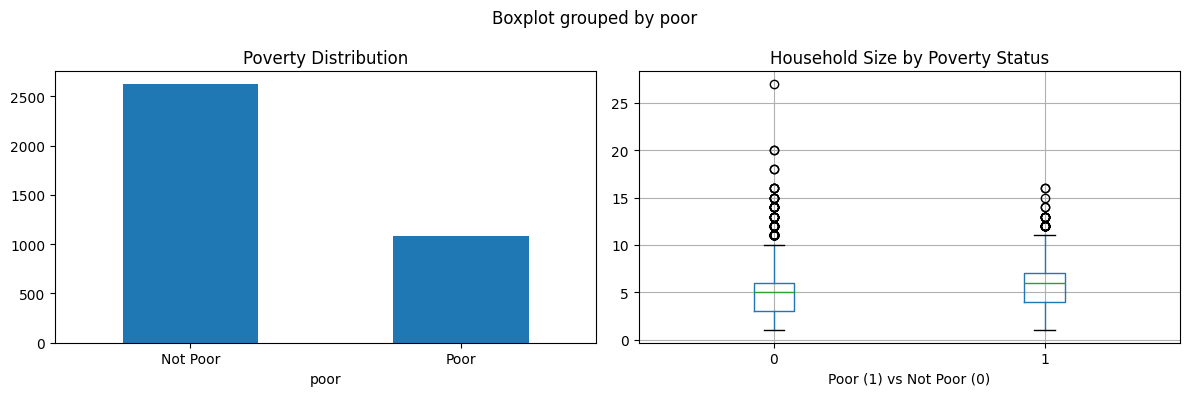

Plot saved


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df = df.copy()


features_to_explore = ['hv009', 'hv025', 'hv219', 'hv106', 
                        'hv201', 'hv205', 'hv206', 'hv207', 
                        'hv208', 'hv209', 'hv210', 'hv211']

existing = [f for f in features_to_explore if f in df.columns]
print("Available features:", existing)


if 'hv025' in df.columns:
    print("\nPoverty by urban/rural:")
    print(df.groupby('hv025')['poor'].mean().round(3))

if 'hv009' in df.columns:
    print("\nHousehold size stats by poverty:")
    print(df.groupby('poor')['hv009'].describe())


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['poor'].value_counts().plot(kind='bar', ax=axes[0], title='Poverty Distribution')
axes[0].set_xticklabels(['Not Poor', 'Poor'], rotation=0)
if 'hv009' in df.columns:
    df.boxplot(column='hv009', by='poor', ax=axes[1])
    axes[1].set_title('Household Size by Poverty Status')
    axes[1].set_xlabel('Poor (1) vs Not Poor (0)')
plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150)
plt.show()
print("Plot saved")

In [ ]:

feature_cols = [
    'hv009',  
    'hv025', 
    'hv219', 
    'hv201',  
    'hv205', 
    'hv206',  
    'hv207',  
    'hv208', 
    'hv209', 
    'hv210',  
    'hv211', 
]

for col in feature_cols:
    print(f"\n{col}:")
    print(f"  Missing: {df[col].isna().sum()}")
    print(f"  Unique values: {df[col].nunique()}")
    print(f"  Sample values: {df[col].unique()[:5]}")


hv009:
  Missing: 0
  Unique values: 19
  Sample values: [9 4 5 6 8]

hv025:
  Missing: 0
  Unique values: 2
  Sample values: ['urban', 'rural']
Categories (2, str): ['urban' < 'rural']

hv219:
  Missing: 0
  Unique values: 2
  Sample values: ['male', 'female']
Categories (2, str): ['male' < 'female']

hv201:
  Missing: 0
  Unique values: 10
  Sample values: ['piped into residence', 'public tap', 'public well', 'well in residence', 'tanker truck']
Categories (10, str): ['piped into residence' < 'public tap' < 'well in residence' < 'public well' ... 'pond, lake' < 'rainwater' < 'tanker truck' < 'bottled water']

hv205:
  Missing: 0
  Unique values: 5
  Sample values: ['own flush toilet', 'trad. pit toilet', 'shared flush toilet', 'no facility, bush', 'vent.imp.pit latrine']
Categories (5, str): ['own flush toilet' < 'shared flush toilet' < 'trad. pit toilet' < 'vent.imp.pit latrine' < 'no facility, bush']

hv206:
  Missing: 0
  Unique values: 2
  Sample values: ['yes', 'no']
Categories

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, roc_auc_score
import numpy as np

df_model = df[feature_cols + ['poor']].copy()

binary_cols = ['hv206', 'hv207', 'hv208', 'hv209', 'hv210', 'hv211']
for col in binary_cols:
    df_model[col] = (df_model[col] == 'yes').astype(int)


df_model['hv025'] = (df_model['hv025'] == 'urban').astype(int)


df_model['hv219'] = (df_model['hv219'] == 'male').astype(int)


df_model = pd.get_dummies(df_model, columns=['hv201', 'hv205'], drop_first=True)

print("Final feature matrix shape:", df_model.shape)
print("Features:", df_model.columns.tolist())


X = df_model.drop('poor', axis=1)
y = df_model['poor']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")


models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000),
    'Decision Tree':       DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'Random Forest':       RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    print(f"\n── {name} ──")
    print(classification_report(y_test, y_pred, target_names=['Not Poor', 'Poor']))
    print(f"AUC-ROC: {auc:.4f}")
    results[name] = {'auc': auc, 'model': model}

Final feature matrix shape: (3703, 23)
Features: ['hv009', 'hv025', 'hv219', 'hv206', 'hv207', 'hv208', 'hv209', 'hv210', 'hv211', 'poor', 'hv201_public tap', 'hv201_well in residence', 'hv201_public well', 'hv201_spring', 'hv201_river, stream', 'hv201_pond, lake', 'hv201_rainwater', 'hv201_tanker truck', 'hv201_bottled water', 'hv205_shared flush toilet', 'hv205_trad. pit toilet', 'hv205_vent.imp.pit latrine', 'hv205_no facility, bush']

Train: (2962, 22), Test: (741, 22)

── Logistic Regression ──
              precision    recall  f1-score   support

    Not Poor       0.99      0.91      0.95       525
        Poor       0.82      0.98      0.89       216

    accuracy                           0.93       741
   macro avg       0.90      0.95      0.92       741
weighted avg       0.94      0.93      0.93       741

AUC-ROC: 0.9856

── Decision Tree ──
              precision    recall  f1-score   support

    Not Poor       0.96      0.92      0.94       525
        Poor       0.8

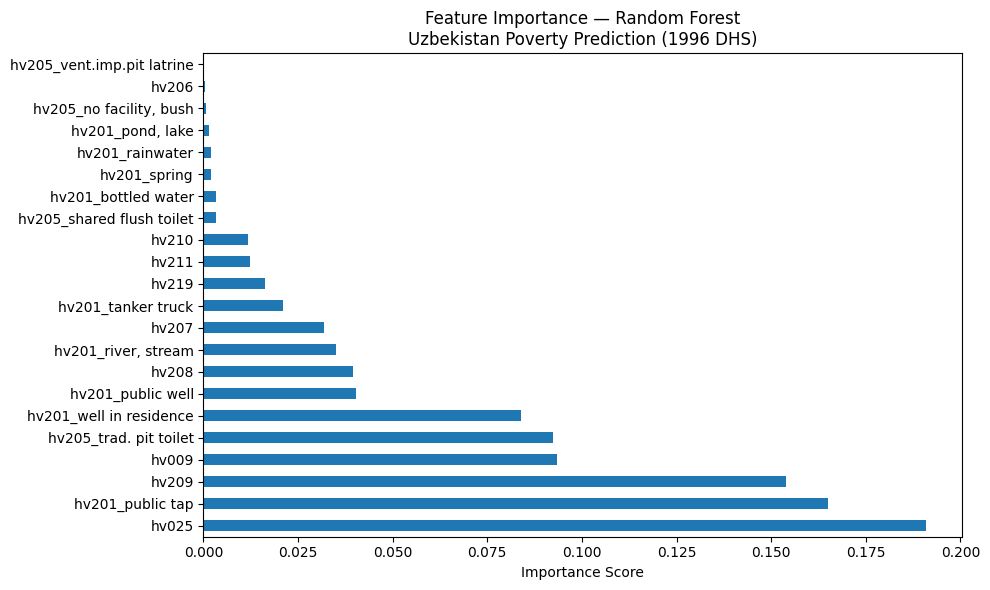


Top 10 features:
hv025                      0.190794
hv201_public tap           0.164905
hv209                      0.153919
hv009                      0.093495
hv205_trad. pit toilet     0.092346
hv201_well in residence    0.083859
hv201_public well          0.040214
hv208                      0.039531
hv201_river, stream        0.034893
hv207                      0.031881
dtype: float64

Top 10 Logistic Regression coefficients (by magnitude):
hv201_river, stream        4.596580
hv201_public tap           4.513763
hv201_well in residence    4.191477
hv201_public well          4.013116
hv205_trad. pit toilet     3.279557
hv201_tanker truck         3.232867
hv209                     -2.891762
hv208                     -2.604297
hv201_bottled water        2.410993
hv201_spring               1.425327
dtype: float64


In [ ]:

importances = pd.Series(
    results['Random Forest']['model'].feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.plot(kind='barh')
plt.title('Feature Importance — Random Forest\nUzbekistan Poverty Prediction (1996 DHS)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print("\nTop 10 features:")
print(importances.head(10))


lr_coefs = pd.Series(
    results['Logistic Regression']['model'].coef_[0],
    index=X_train.columns
).sort_values(key=abs, ascending=False)

print("\nTop 10 Logistic Regression coefficients (by magnitude):")
print(lr_coefs.head(10))

In [ ]:

print("\n" + "="*65)
print(f"{'Model':<25} {'Accuracy':>10} {'AUC-ROC':>10} {'Poor F1':>10}")
print("="*65)
data = {
    'Logistic Regression': (0.93, 0.9856, 0.89),
    'Decision Tree':       (0.92, 0.9395, 0.87),
    'Random Forest':       (0.92, 0.9784, 0.87),
    'Gradient Boosting':   (0.94, 0.9817, 0.89),
}
for name, (acc, auc, f1) in data.items():
    print(f"{name:<25} {acc:>10.2%} {auc:>10.4f} {f1:>10.2f}")
print("="*65)


df_model.to_csv('uzbekistan_1996_processed.csv', index=False)
print("\nProcessed dataset saved.")


Model                       Accuracy    AUC-ROC    Poor F1
Logistic Regression           93.00%     0.9856       0.89
Decision Tree                 92.00%     0.9395       0.87
Random Forest                 92.00%     0.9784       0.87
Gradient Boosting             94.00%     0.9817       0.89

Processed dataset saved.
